In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import pearsonr, ttest_1samp
from statsmodels.stats.multitest import multipletests

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/shared_helper_modules/')

from config import SPE1_PICKLE_ROOT, CELL_IDS, DICT_CELL_TYPE
from spikeparam_plotting import plot_corr_heatmap_only_spk

plt.rcParams['font.family'] = 'Helvetica Neue'

SPE1_PKL = SPE1_PICKLE_ROOT
PVC6_PKL = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles'

SPK_FEATS = ['ramp_amp', 'inflection_time', 'inflection_amp',
              'peak_amp', 'peak_width', 'peak_sharpness',
              'exp_lambda', 'exp_const', 'log_isi']

In [2]:
def compute_within_cell_avg_corr(dfs, feat_cols):
    """Per-cell Pearson r, nanmean across cells, one-sample t-test + FDR.

    Parameters
    ----------
    dfs : list of DataFrames, one per cell
    feat_cols : list of feature column names

    Returns
    -------
    mean_r   : (n, n) average Pearson r across cells
    pval_mat : (n, n) FDR-corrected p-values (one-sample t-test vs 0)
    n_cells  : number of cells that contributed
    """
    n = len(feat_cols)
    cell_mats = []
    for df in dfs:
        sub = df[[c for c in feat_cols if c in df.columns]].dropna()
        if len(sub) < 5:
            continue
        # fill missing features with NaN so matrices align
        sub = sub.reindex(columns=feat_cols)
        r_mat = np.full((n, n), np.nan)
        for i, ci in enumerate(feat_cols):
            for j, cj in enumerate(feat_cols):
                if i == j:
                    r_mat[i, j] = 1.0
                elif ci in sub.columns and cj in sub.columns:
                    _v = sub[[ci, cj]].dropna()
                    if len(_v) > 4:
                        r_mat[i, j], _ = pearsonr(_v[ci], _v[cj])
        cell_mats.append(r_mat)

    if not cell_mats:
        return np.full((n, n), np.nan), np.full((n, n), np.nan), 0

    stack    = np.stack(cell_mats)          # (n_cells, n, n)
    mean_r   = np.nanmean(stack, axis=0)
    np.fill_diagonal(mean_r, 1.0)

    # One-sample t-test per lower-triangle pair against r=0
    lower_idx = [(i, j) for i in range(n) for j in range(i)]
    raw_ps    = []
    for i, j in lower_idx:
        vals = stack[:, i, j]
        vals = vals[~np.isnan(vals)]
        if len(vals) > 2:
            _, p = ttest_1samp(vals, 0)
        else:
            p = 1.0
        raw_ps.append(p)

    _, pvals_fdr, _, _ = multipletests(raw_ps, method='fdr_bh')

    pval_mat = np.ones((n, n))
    for (i, j), pc in zip(lower_idx, pvals_fdr):
        pval_mat[i, j] = pc
        pval_mat[j, i] = pc

    return mean_r, pval_mat, len(cell_mats)


def plot_avg_corr_heatmap(mean_r, pval_mat, feat_cols, title='',
                           corr_threshold=0.1, figsize=(14, 11)):
    """Same aesthetic as plot_corr_heatmap_only_spk but on a pre-averaged matrix."""
    _LABEL = {
        'ramp_amp':        'ramp amp',
        'inflection_time': 'inflec time',
        'inflection_amp':  'inflec amp',
        'peak_amp':        'peak amp',
        'peak_width':      'peak width',
        'peak_sharpness':  'peak sharp',
        'exp_lambda':      'exp lambda',
        'exp_const':       'exp const',
        'log_isi':         'log ISI',
    }
    def _short(f): return _LABEL.get(f, f.replace('_', ' '))
    def _y_label(f):
        s = _short(f)
        parts = s.split(' ')
        return parts[0] + '\n' + parts[1] if len(parts) == 2 else s

    n = len(feat_cols)
    rho_df   = pd.DataFrame(mean_r,   index=feat_cols, columns=feat_cols)
    pval_df  = pd.DataFrame(pval_mat, index=feat_cols, columns=feat_cols)

    mask     = np.triu(np.ones((n, n), dtype=bool))
    xlabels  = [_short(f) for f in feat_cols[:-1]] + ['']
    ylabels  = [''] + [_y_label(f) for f in feat_cols[1:]]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(rho_df, mask=mask, annot=False, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0, ax=ax,
                xticklabels=xlabels, yticklabels=ylabels)

    cbar = ax.collections[0].colorbar
    cbar.set_ticks([-1, 0, 1])
    cbar.set_ticklabels(['-1', '0', '1'])
    cbar.ax.tick_params(labelsize=22, width=2.5, length=6)
    for spine in cbar.ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(2.5); spine.set_color('#1a1a1a')
    for label in cbar.ax.get_yticklabels():
        label.set_fontweight('bold'); label.set_fontfamily('Helvetica Neue')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(2.5)
        ax.spines[spine].set_color('#1a1a1a')

    _cmap_obj = plt.cm.RdBu_r
    _norm_obj = mcolors.Normalize(vmin=-1, vmax=1)
    cell_h_in = figsize[1] / n
    star_fs   = max(14, int(cell_h_in * 72 * 0.45))
    r_fs      = max(10, int(cell_h_in * 72 * 0.26))

    for i in range(n):
        for j in range(n):
            if i > j:
                r_val = mean_r[i, j]
                p     = pval_mat[i, j]
                sig   = p < 0.05 and abs(r_val) >= corr_threshold
                rgba      = _cmap_obj(_norm_obj(r_val))
                luminance = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
                txt_color = 'white' if luminance < 0.5 else 'black'

                ax.text(j + 0.5, i + 0.68, f'{r_val:.2f}',
                        ha='center', va='center', fontsize=r_fs, color=txt_color,
                        fontweight='bold' if p < 0.05 else 'normal',
                        fontfamily='Helvetica Neue')
                if sig:
                    star = '***' if p < 0.001 else '**' if p < 0.01 else '*'
                    ax.text(j + 0.5, i + 0.32, star,
                            ha='center', va='center', fontsize=star_fs,
                            fontweight='bold', color=txt_color,
                            fontfamily='Helvetica Neue')

    ax.tick_params(axis='x', which='major', labelsize=32, width=2.5)
    ax.tick_params(axis='y', which='major', labelsize=28, width=2.5)
    fig.canvas.draw()
    for label in ax.get_xticklabels():
        label.set_fontweight('bold'); label.set_fontfamily('Helvetica Neue')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold'); label.set_fontfamily('Helvetica Neue')
        label.set_multialignment('center')
    if title:
        ax.set_title(title, fontsize=22, fontweight='bold', fontfamily='Helvetica Neue')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [3]:
# ── pvc-6 ─────────────────────────────────────────────────────────────────────
with open(os.path.join(PVC6_PKL, 'df_all_c1.pkl'), 'rb') as f:
    df_pvc6_c1 = pickle.load(f)
with open(os.path.join(PVC6_PKL, 'df_all_c2.pkl'), 'rb') as f:
    df_pvc6_c2 = pickle.load(f)

# ── spe-1: load per-cell cluster dfs ──────────────────────────────────────────
_cluster_dir = os.path.join(SPE1_PKL, 'cluster_pickles')
dfs_pc   = []
dfs_in   = []
dfs_all  = []
cids_pc  = []
cids_in  = []
cids_all = []

for _cid in CELL_IDS:
    _p = os.path.join(_cluster_dir, f'{_cid}_cluster_df.pkl')
    if not os.path.exists(_p):
        continue
    with open(_p, 'rb') as _f:
        _df = pickle.load(_f)
    _cnum  = int(_cid.replace('c', ''))
    _ctype = DICT_CELL_TYPE.get(_cnum, 'PC')
    dfs_all.append(_df);  cids_all.append(_cid)
    if _ctype == 'IN':
        dfs_in.append(_df);  cids_in.append(_cid)
    else:
        dfs_pc.append(_df);  cids_pc.append(_cid)

print(f'spe-1 — PC: {len(dfs_pc)} cells, IN: {len(dfs_in)} cells, all: {len(dfs_all)} cells')

# ── Find IN and PC cells with most spikes ─────────────────────────────────────
_best_in_idx = int(np.argmax([len(df) for df in dfs_in]))
_best_pc_idx = int(np.argmax([len(df) for df in dfs_pc]))

best_in_cid = cids_in[_best_in_idx]
best_pc_cid = cids_pc[_best_pc_idx]
best_in_df  = dfs_in[_best_in_idx]
best_pc_df  = dfs_pc[_best_pc_idx]

print(f'IN cell with most spikes: {best_in_cid}  ({len(best_in_df)} spikes)')
print(f'PC cell with most spikes: {best_pc_cid}  ({len(best_pc_df)} spikes)')

spe-1 — PC: 35 cells, IN: 5 cells, all: 40 cells
IN cell with most spikes: c7  (11997 spikes)
PC cell with most spikes: c21  (12556 spikes)


## 1. pvc-6 Cell 2  
Single cell — within-cell correlations directly.

## 0. pvc-6 Cell 1  
Single cell — within-cell correlations directly.

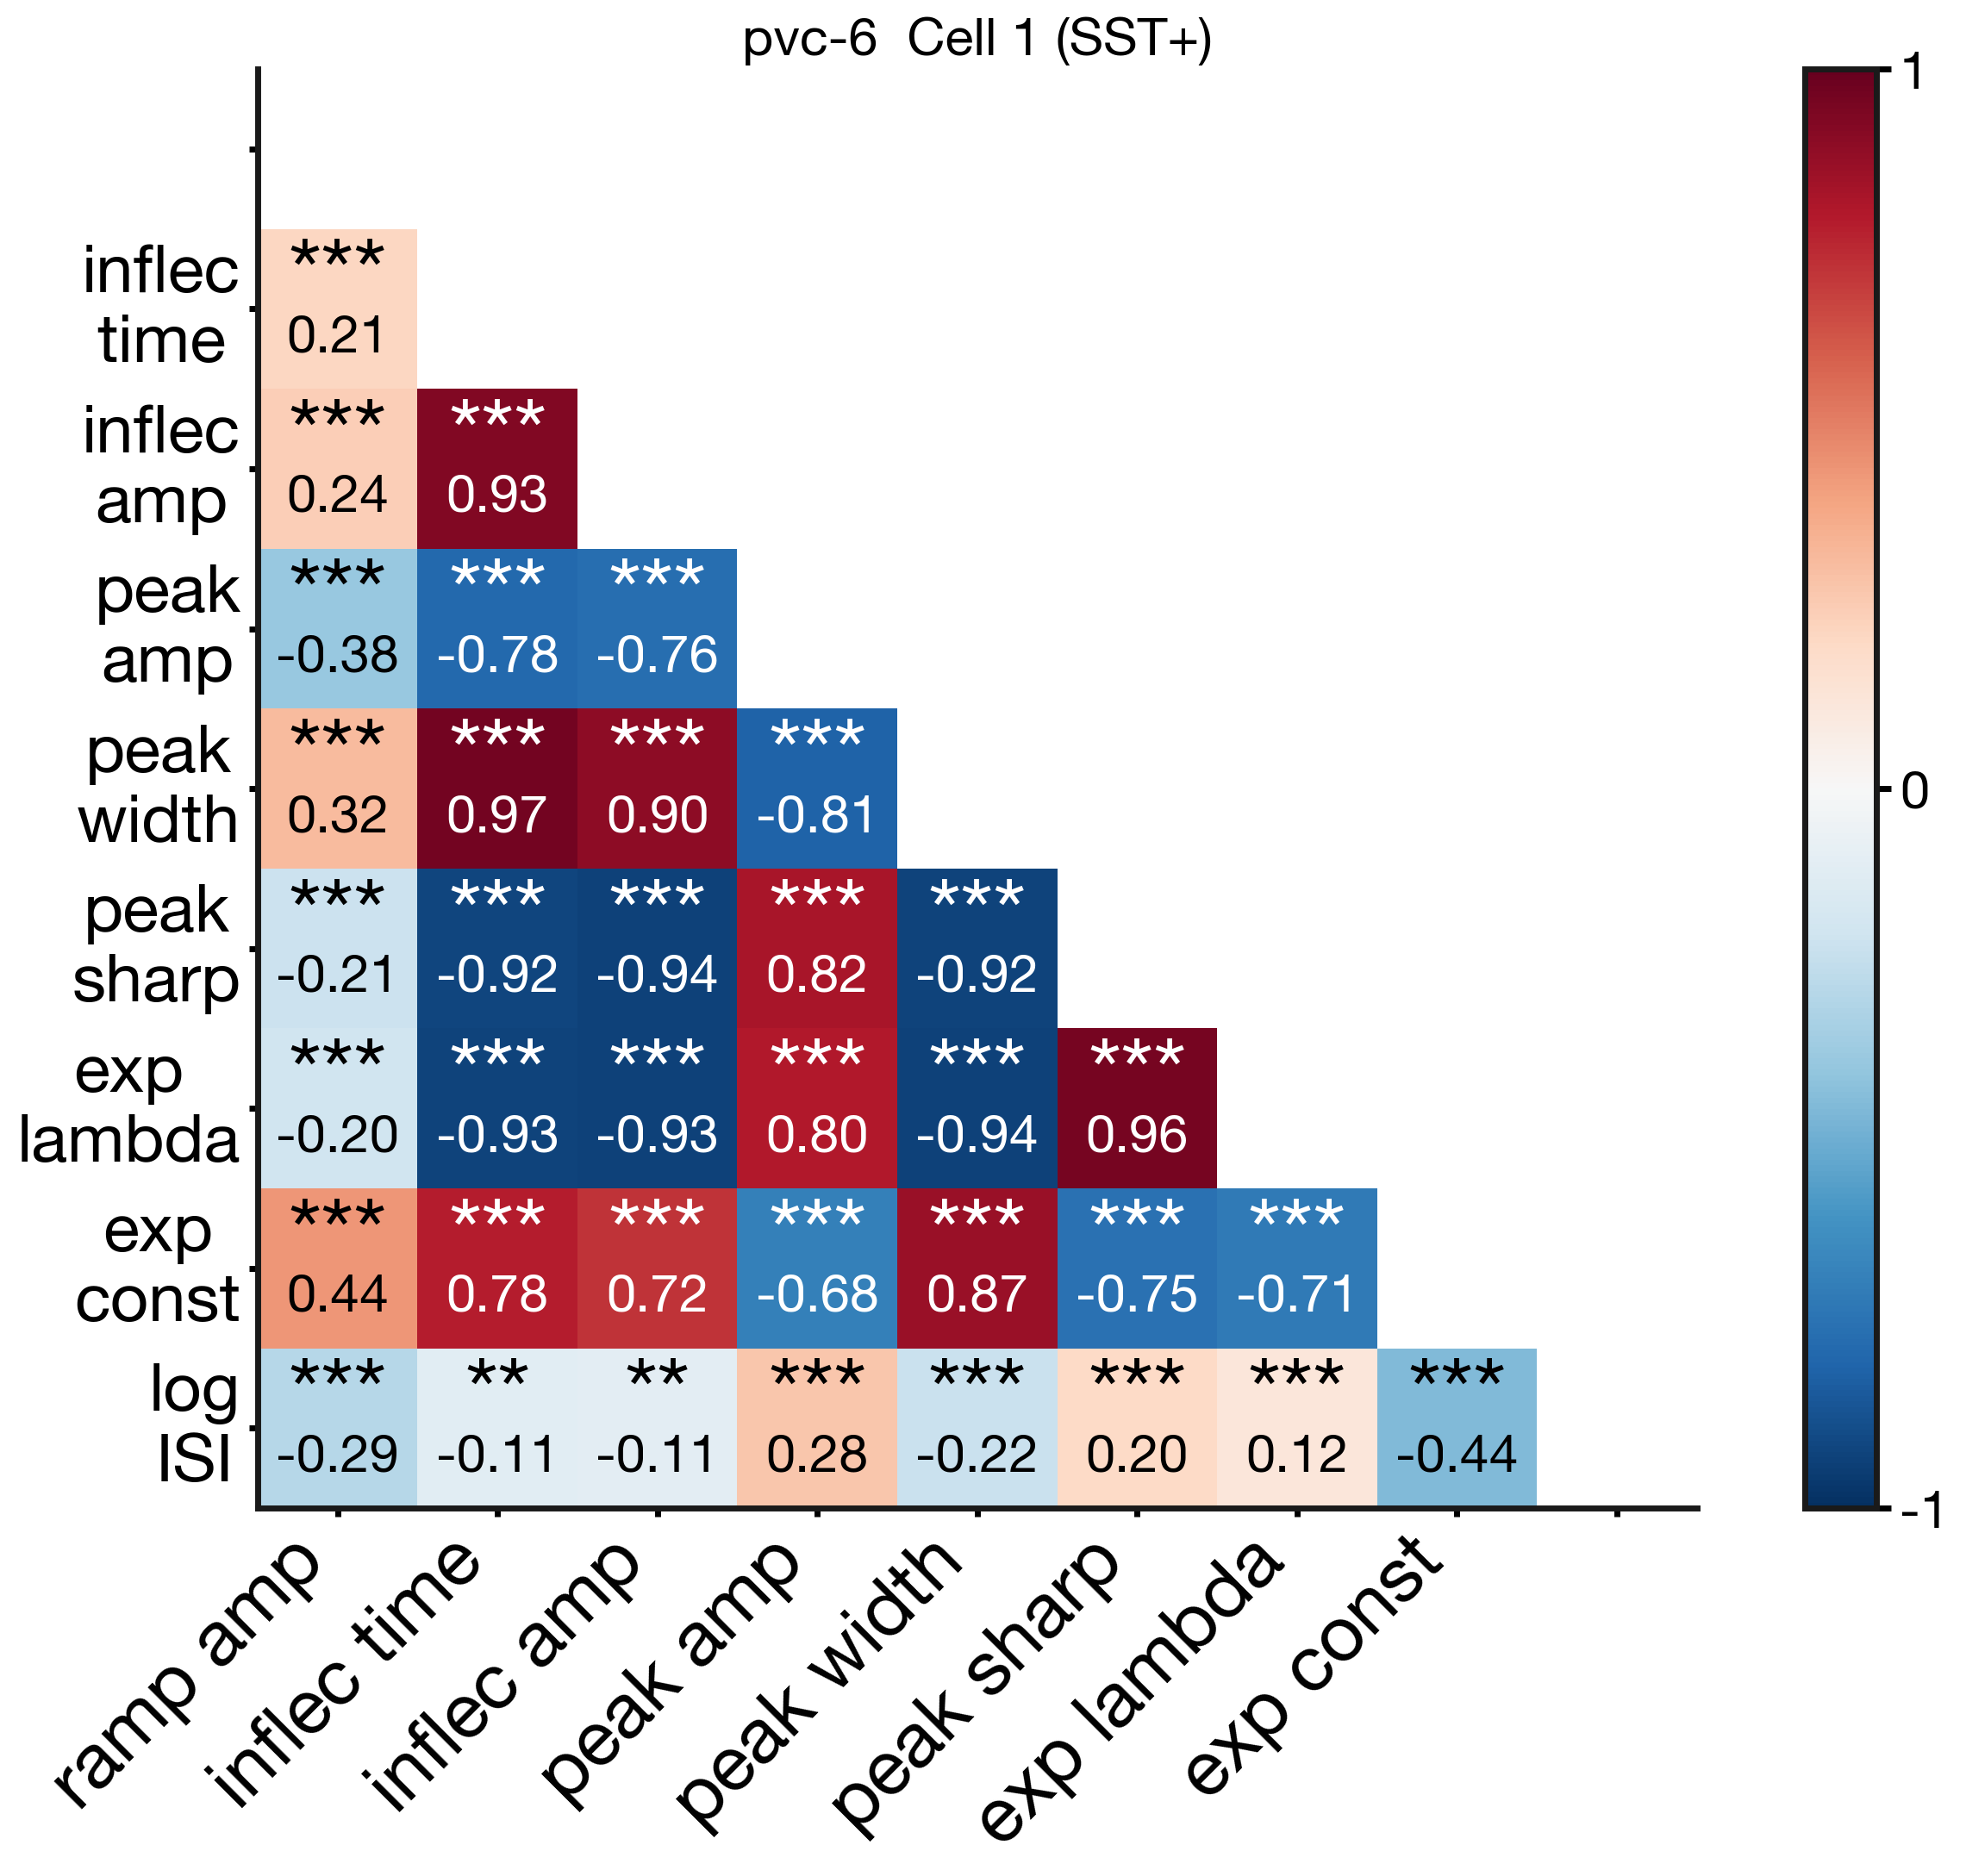

In [4]:
plot_corr_heatmap_only_spk(
    df_pvc6_c1,
    SPK_FEATS,
    title='pvc-6  Cell 1 (SST+)'
)

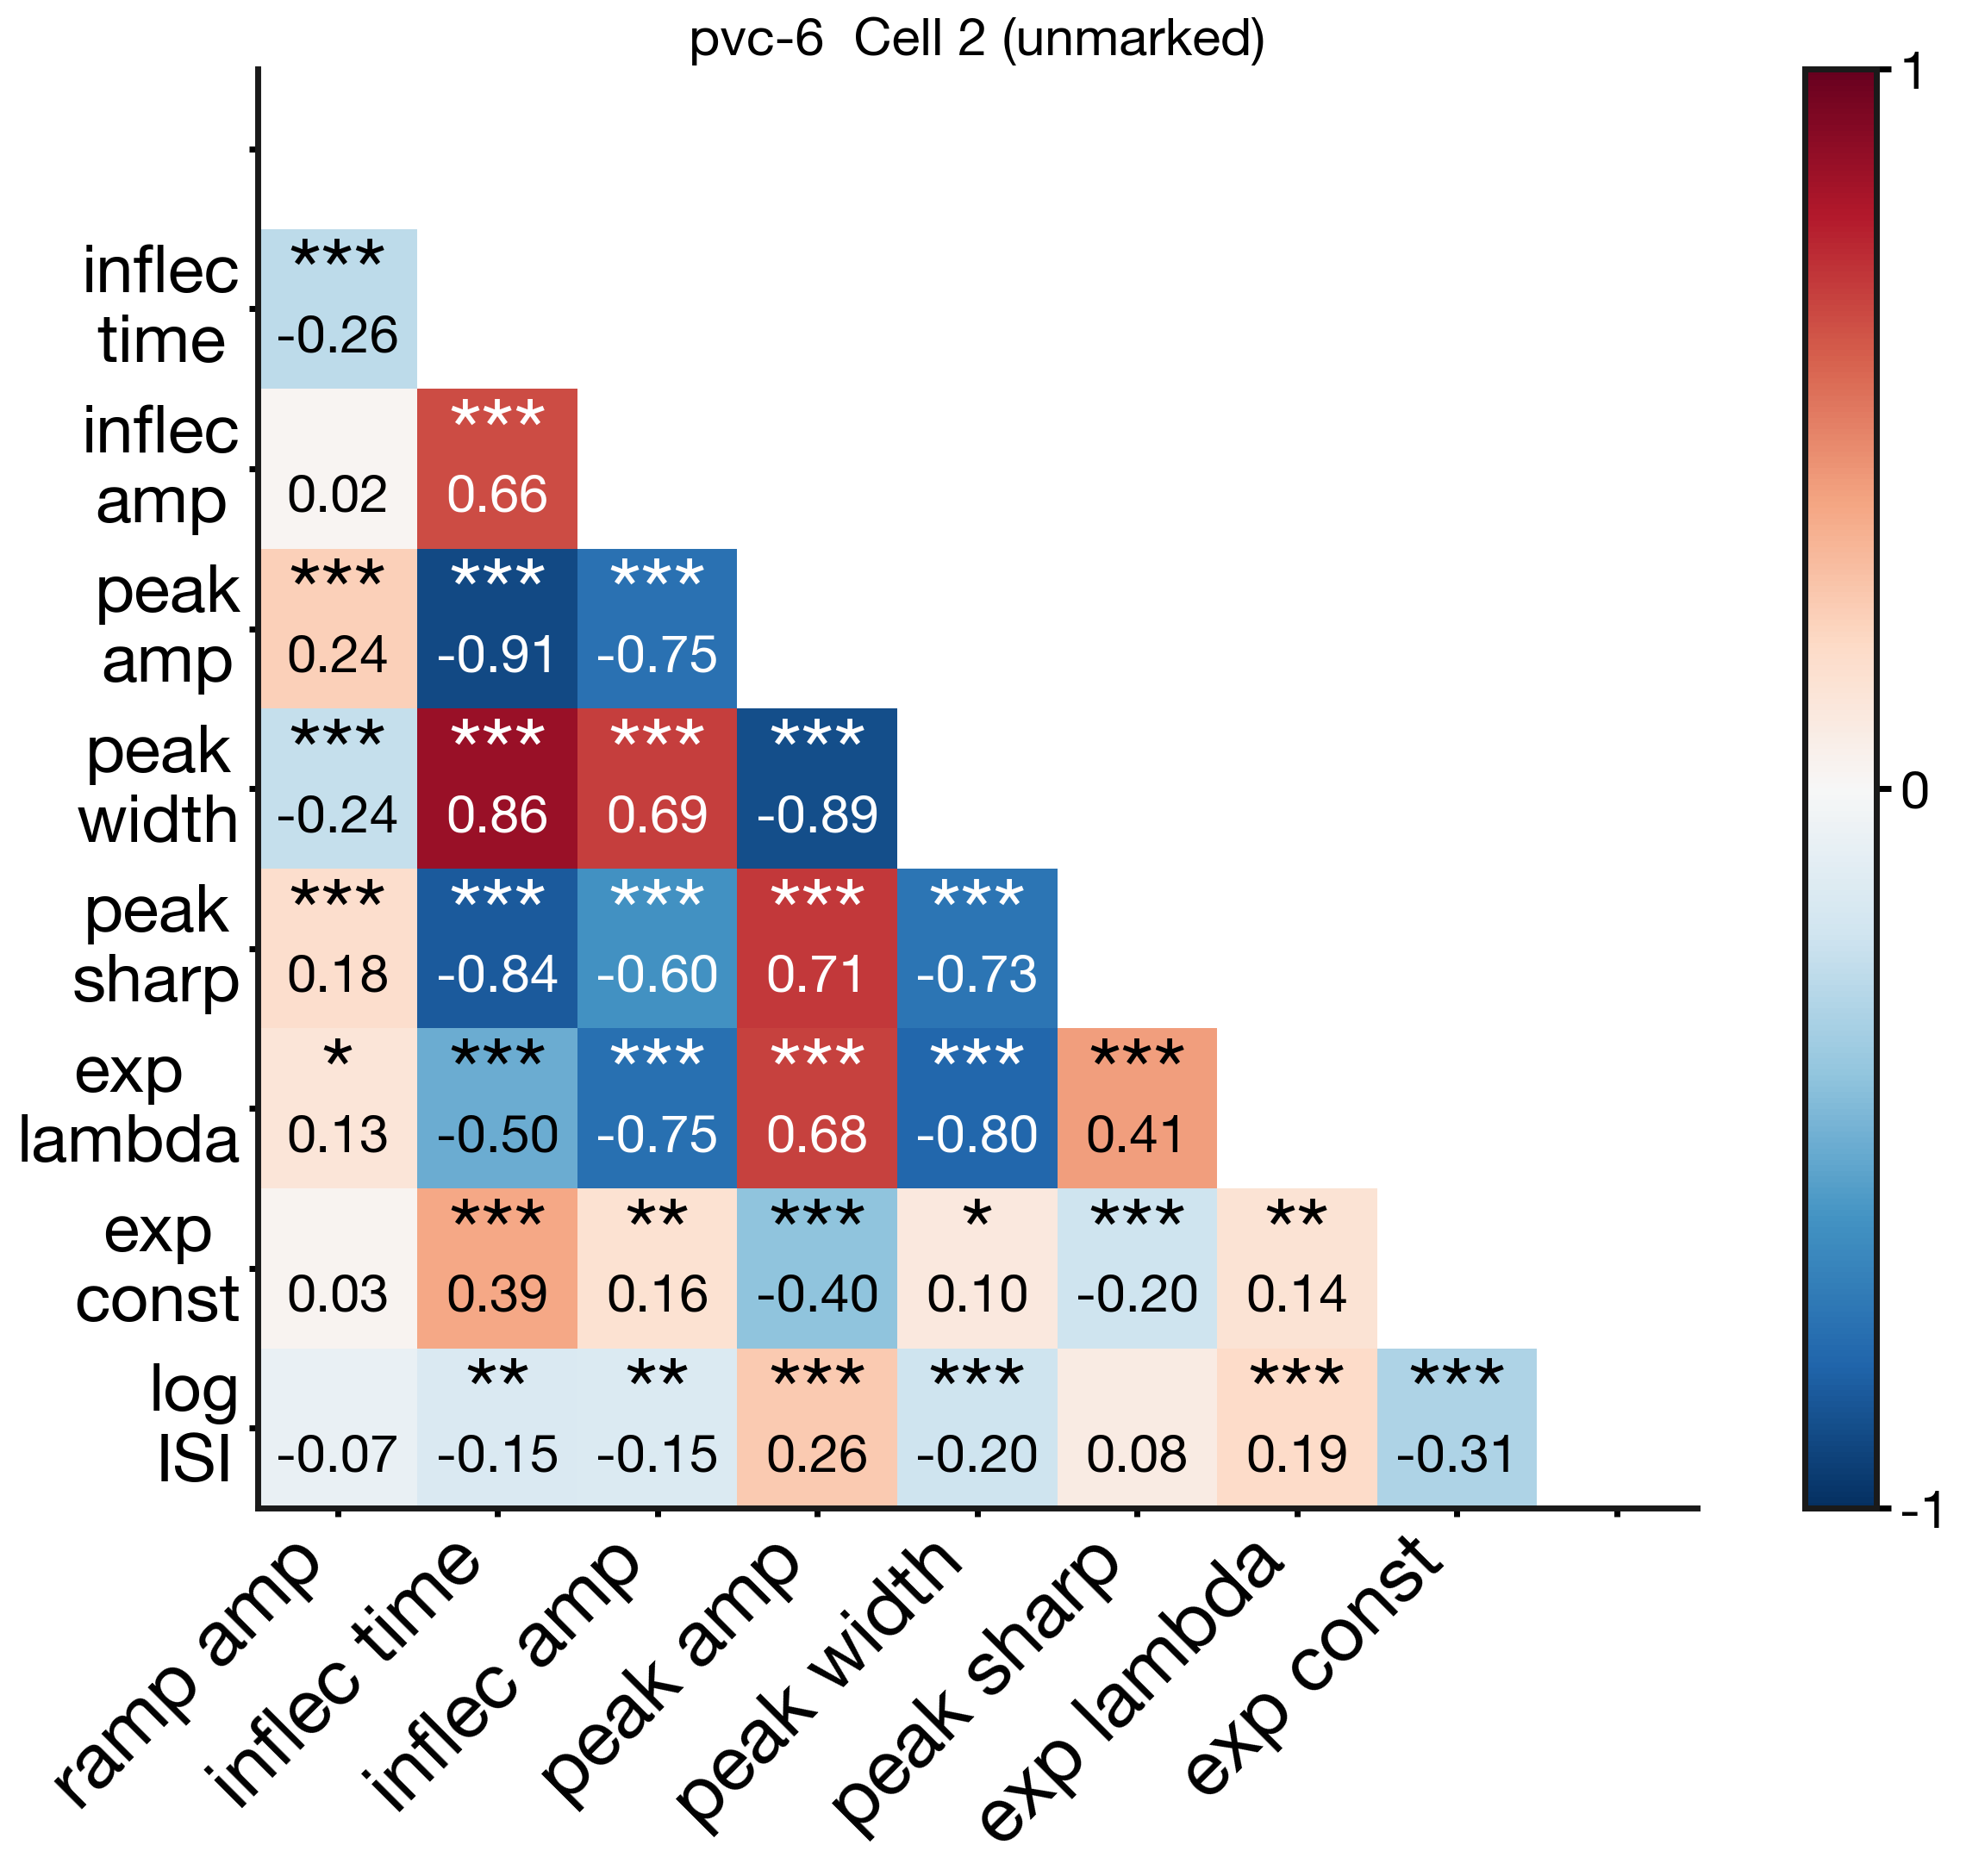

In [5]:
plot_corr_heatmap_only_spk(
    df_pvc6_c2,
    SPK_FEATS,
    title='pvc-6  Cell 2 (unmarked)'
)

## 2. spe-1 — putative IN  
Average within-cell Pearson r across IN cells. Stars = one-sample t-test vs 0, FDR corrected.

IN cells used: 5


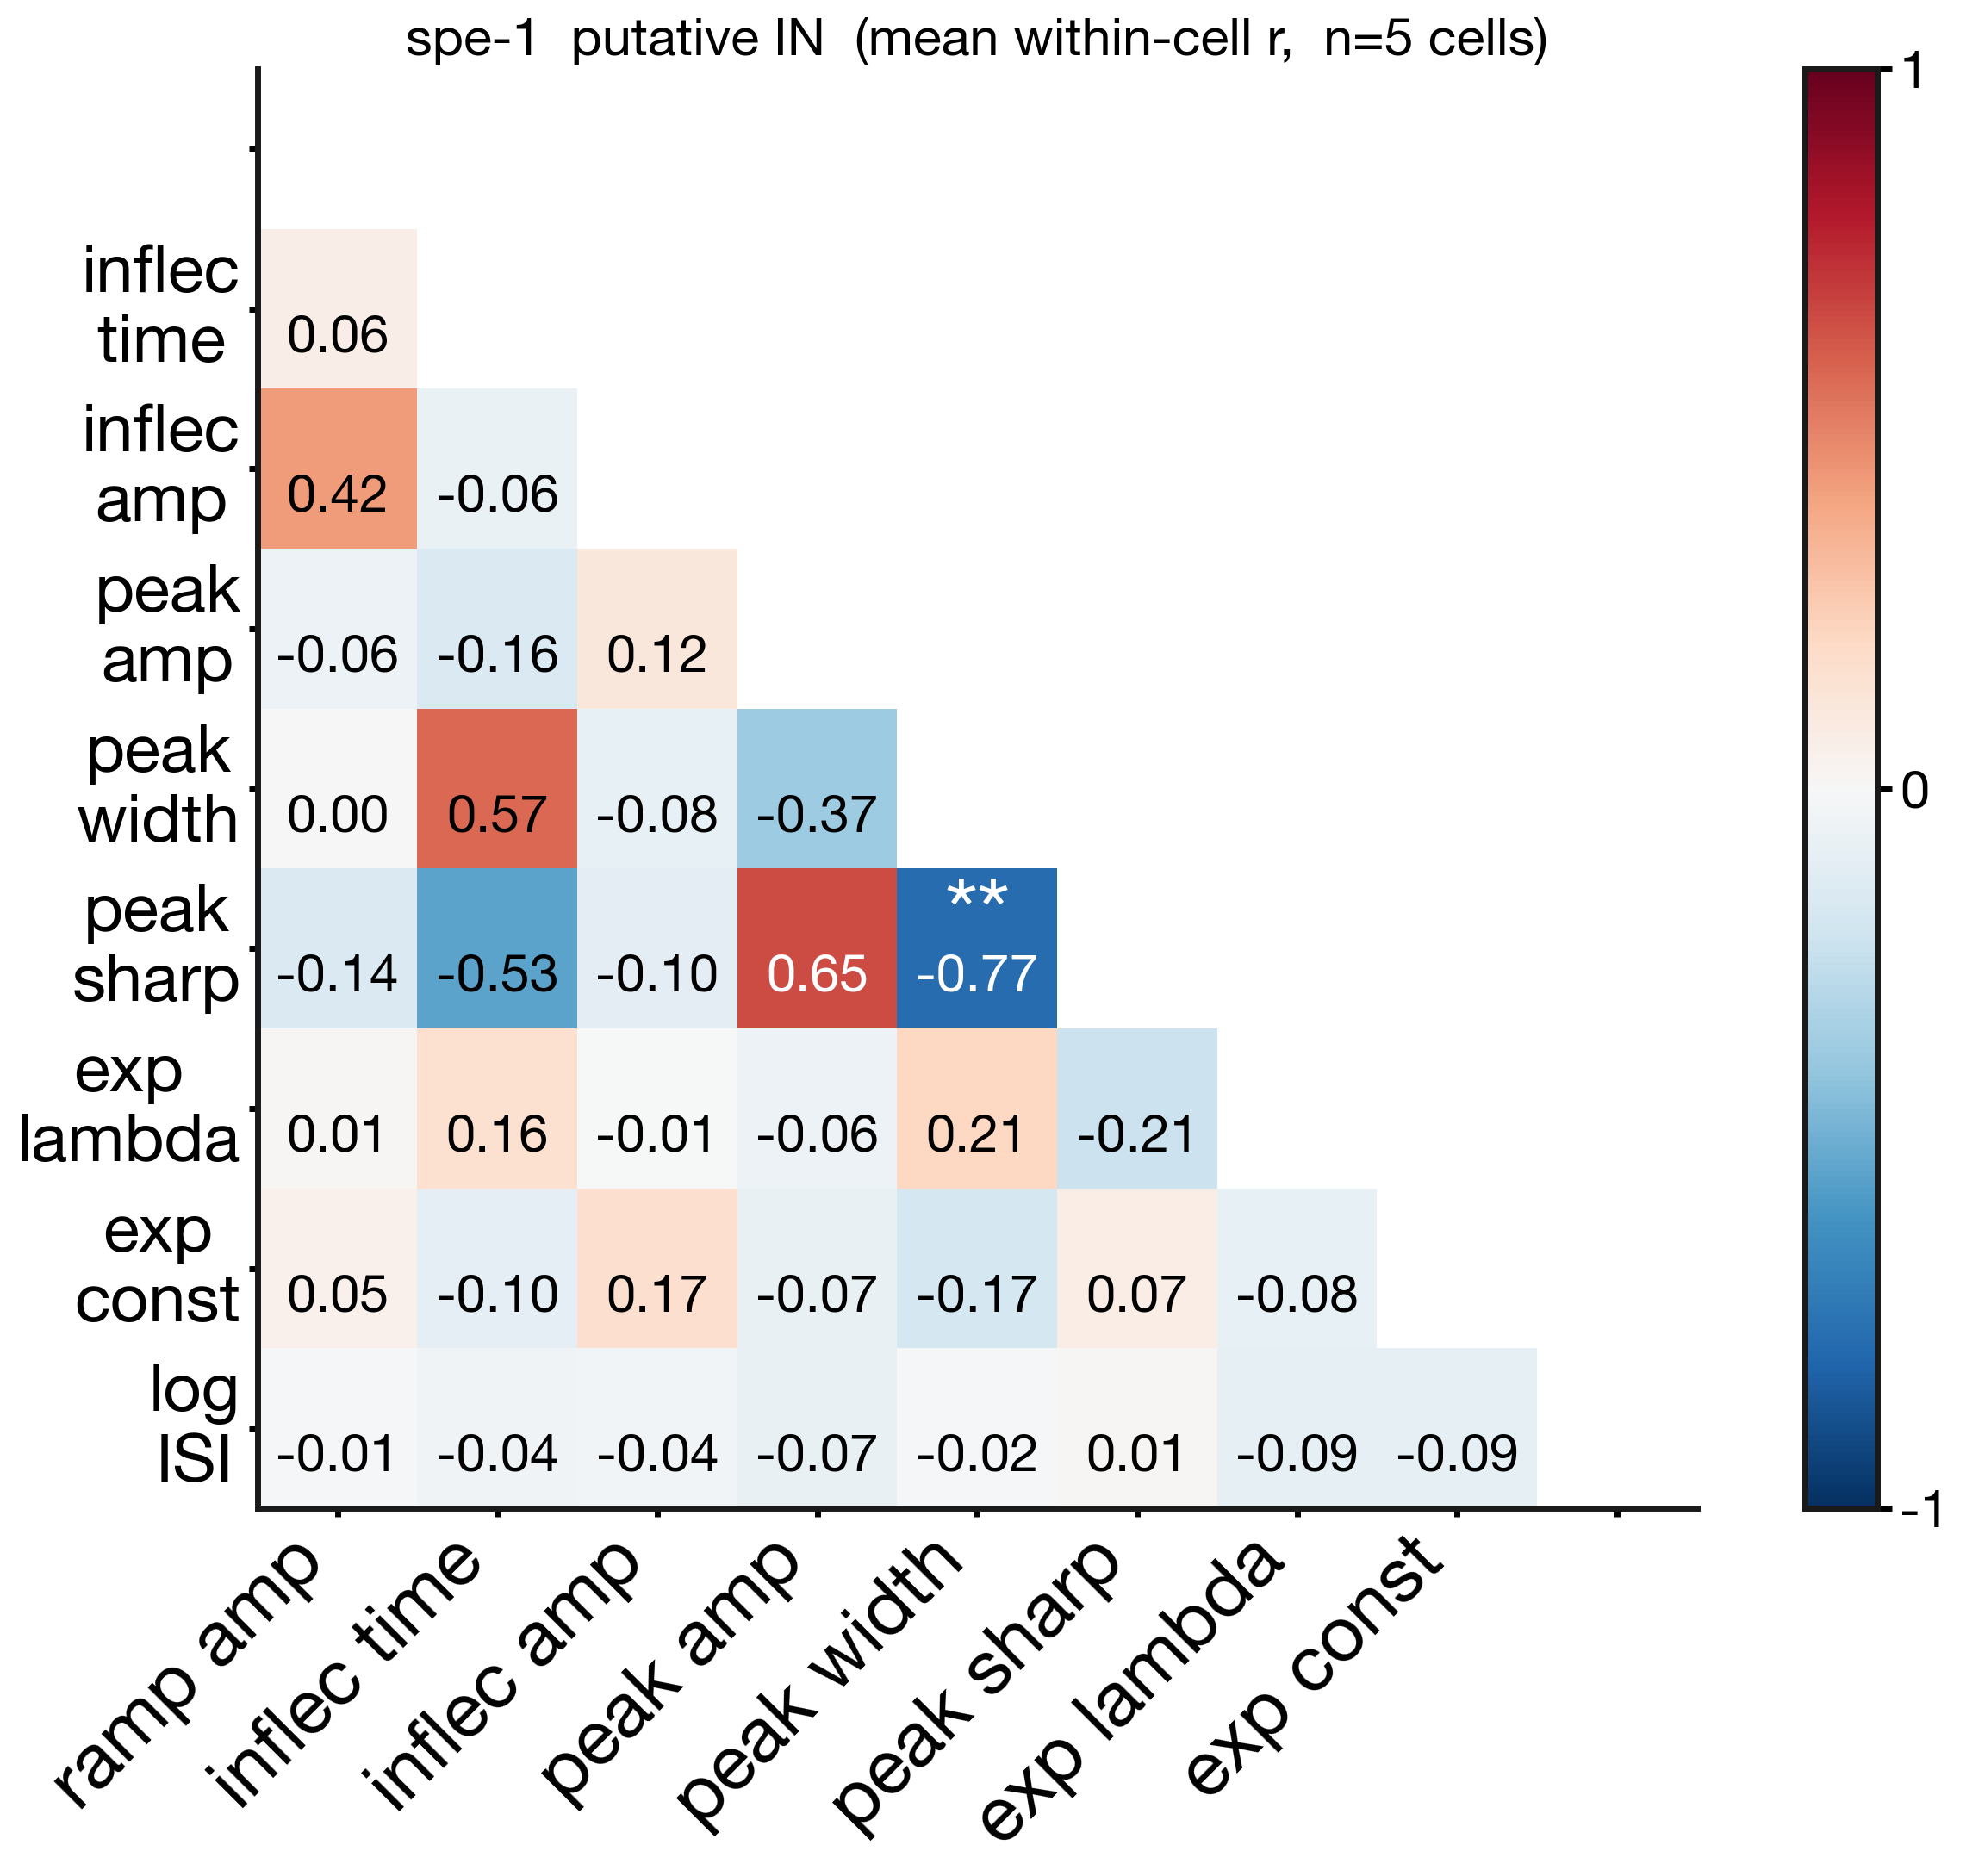

In [6]:
mean_r_in, pval_in, n_in = compute_within_cell_avg_corr(dfs_in, SPK_FEATS)
print(f'IN cells used: {n_in}')
plot_avg_corr_heatmap(
    mean_r_in, pval_in, SPK_FEATS,
    title=f'spe-1  putative IN  (mean within-cell r,  n={n_in} cells)'
)

## 3. spe-1 — putative PC  
Average within-cell Pearson r across PC cells.

PC cells used: 35


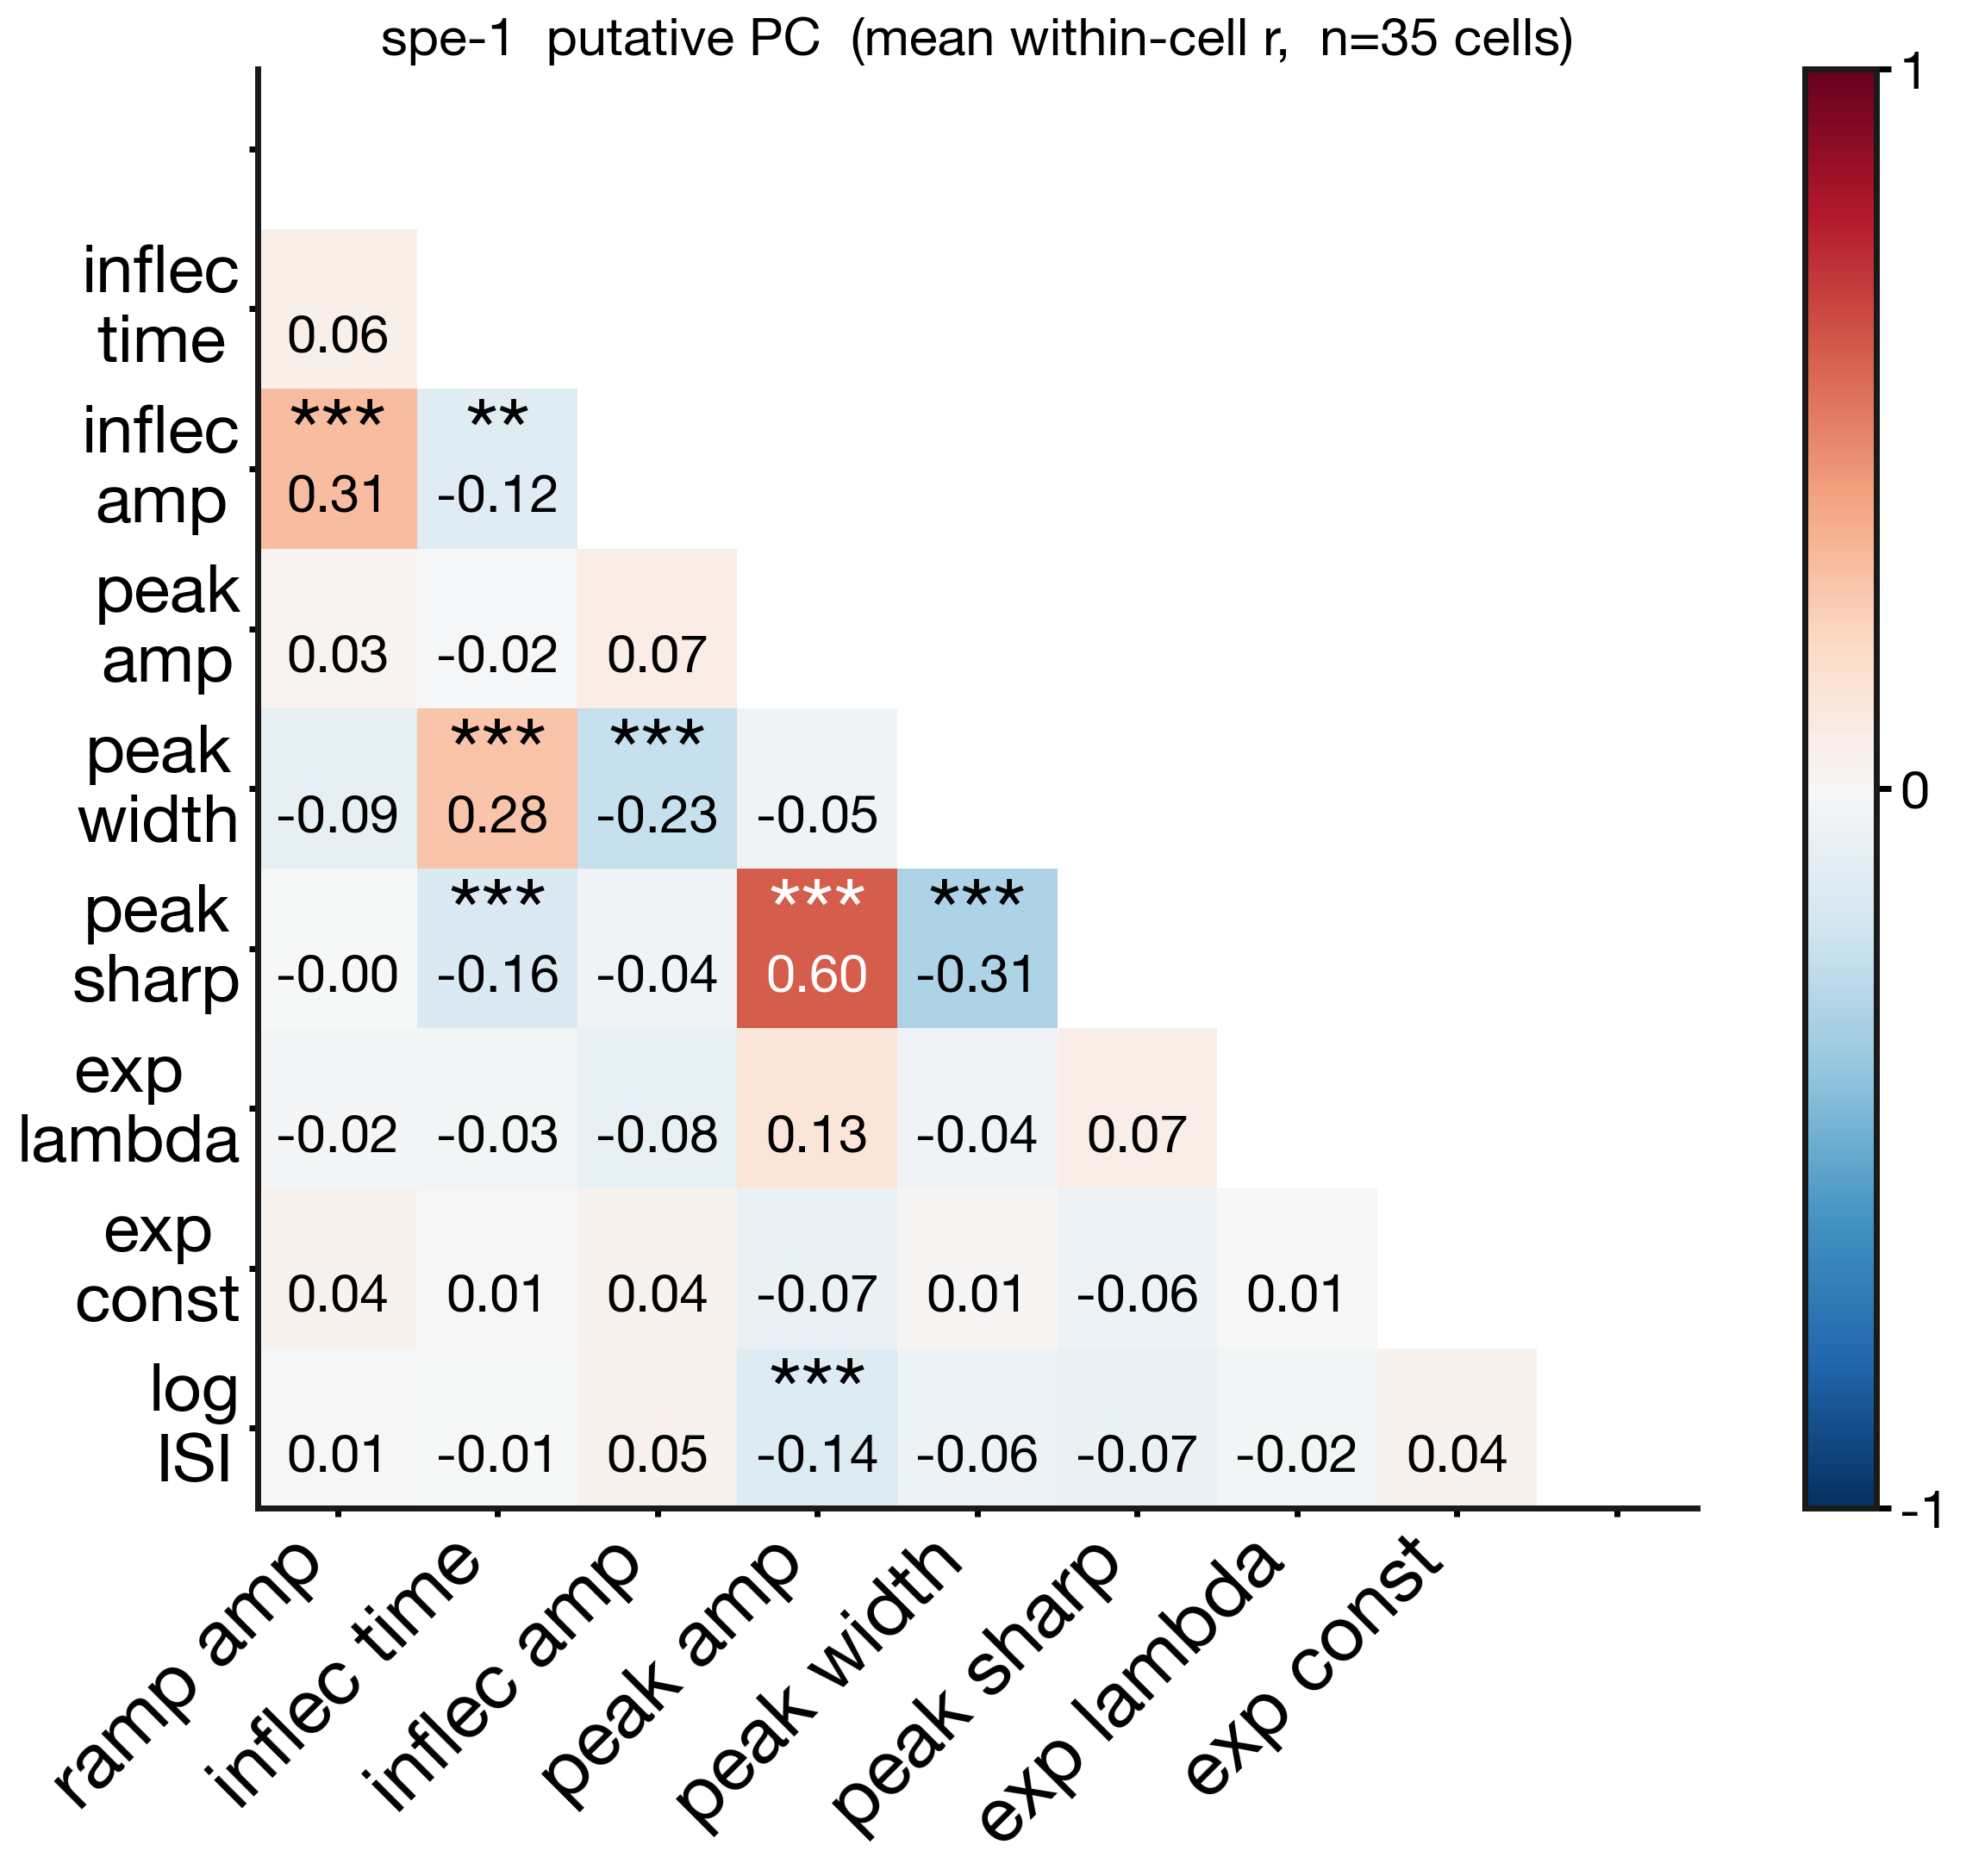

In [7]:
mean_r_pc, pval_pc, n_pc = compute_within_cell_avg_corr(dfs_pc, SPK_FEATS)
print(f'PC cells used: {n_pc}')
plot_avg_corr_heatmap(
    mean_r_pc, pval_pc, SPK_FEATS,
    title=f'spe-1  putative PC  (mean within-cell r,  n={n_pc} cells)'
)

## 4. spe-1 — all cells  
Average within-cell Pearson r across all spe-1 cells.

spe-1 cells used: 40


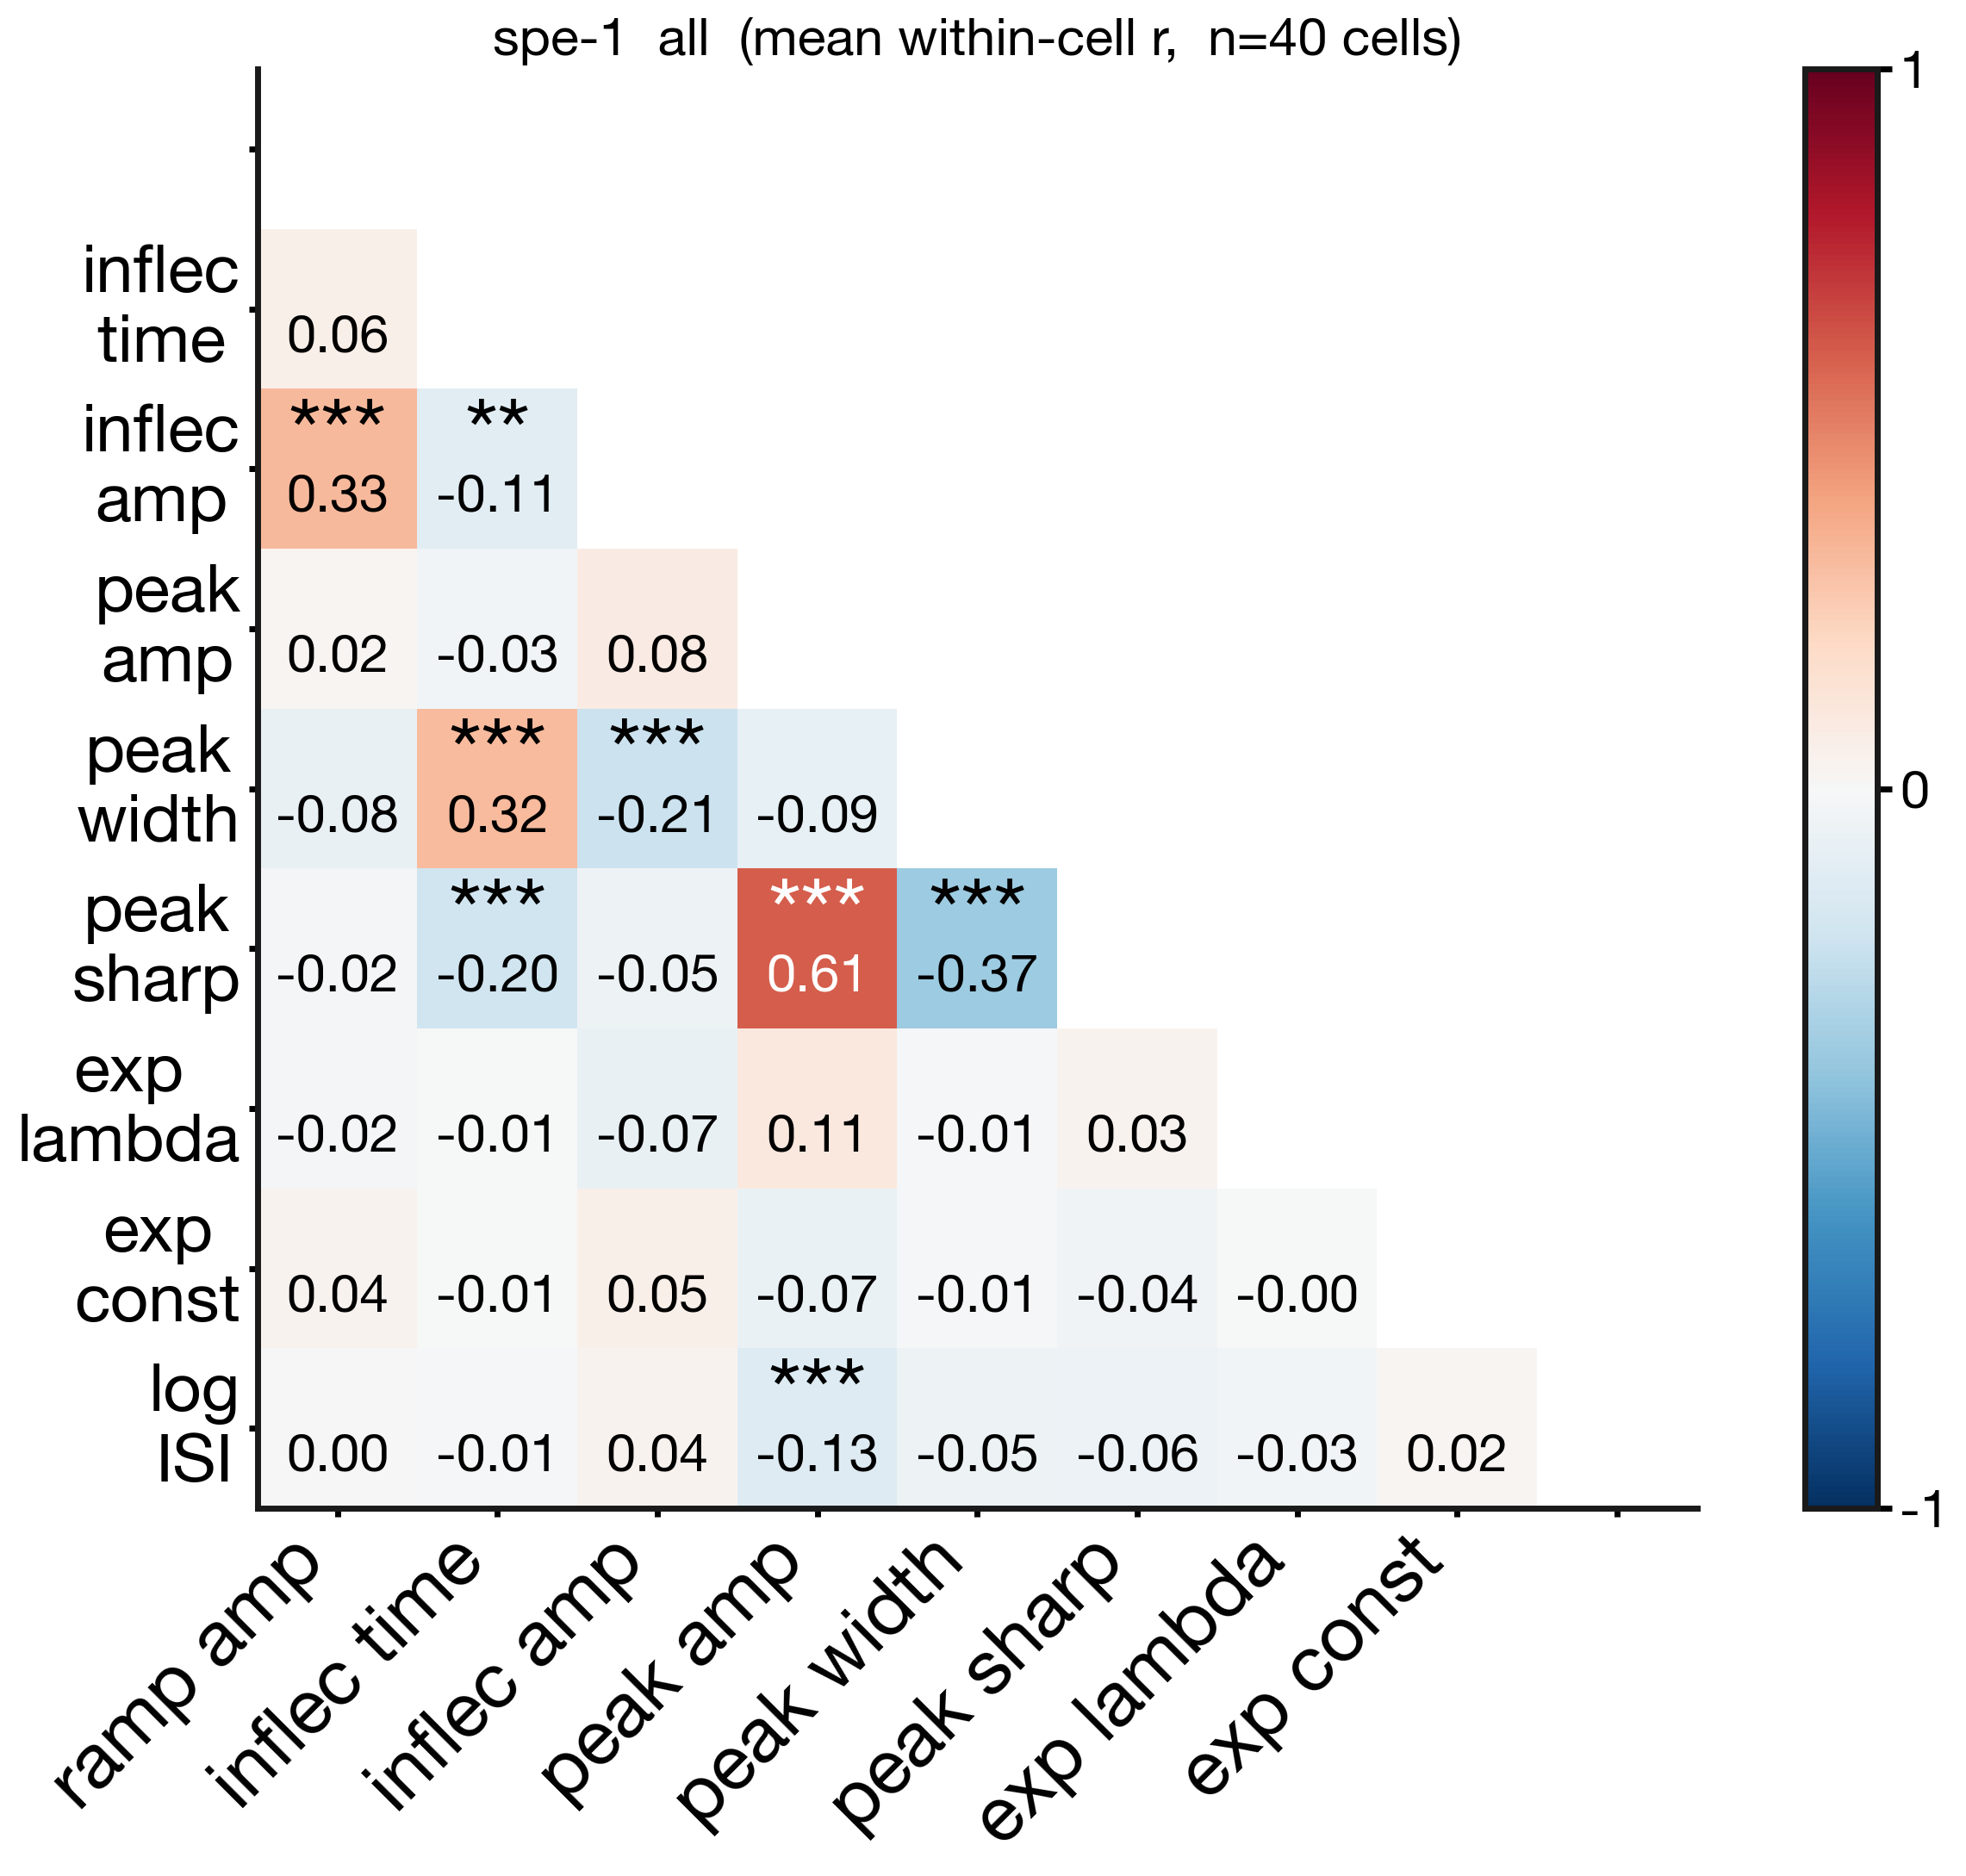

In [8]:
mean_r_spe1, pval_spe1, n_spe1 = compute_within_cell_avg_corr(dfs_all, SPK_FEATS)
print(f'spe-1 cells used: {n_spe1}')
plot_avg_corr_heatmap(
    mean_r_spe1, pval_spe1, SPK_FEATS,
    title=f'spe-1  all  (mean within-cell r,  n={n_spe1} cells)'
)

## 5. All data (spe-1 + pvc-6)  
Average within-cell Pearson r across all spe-1 cells + pvc-6 cells 1 and 2.

total cells used: 42


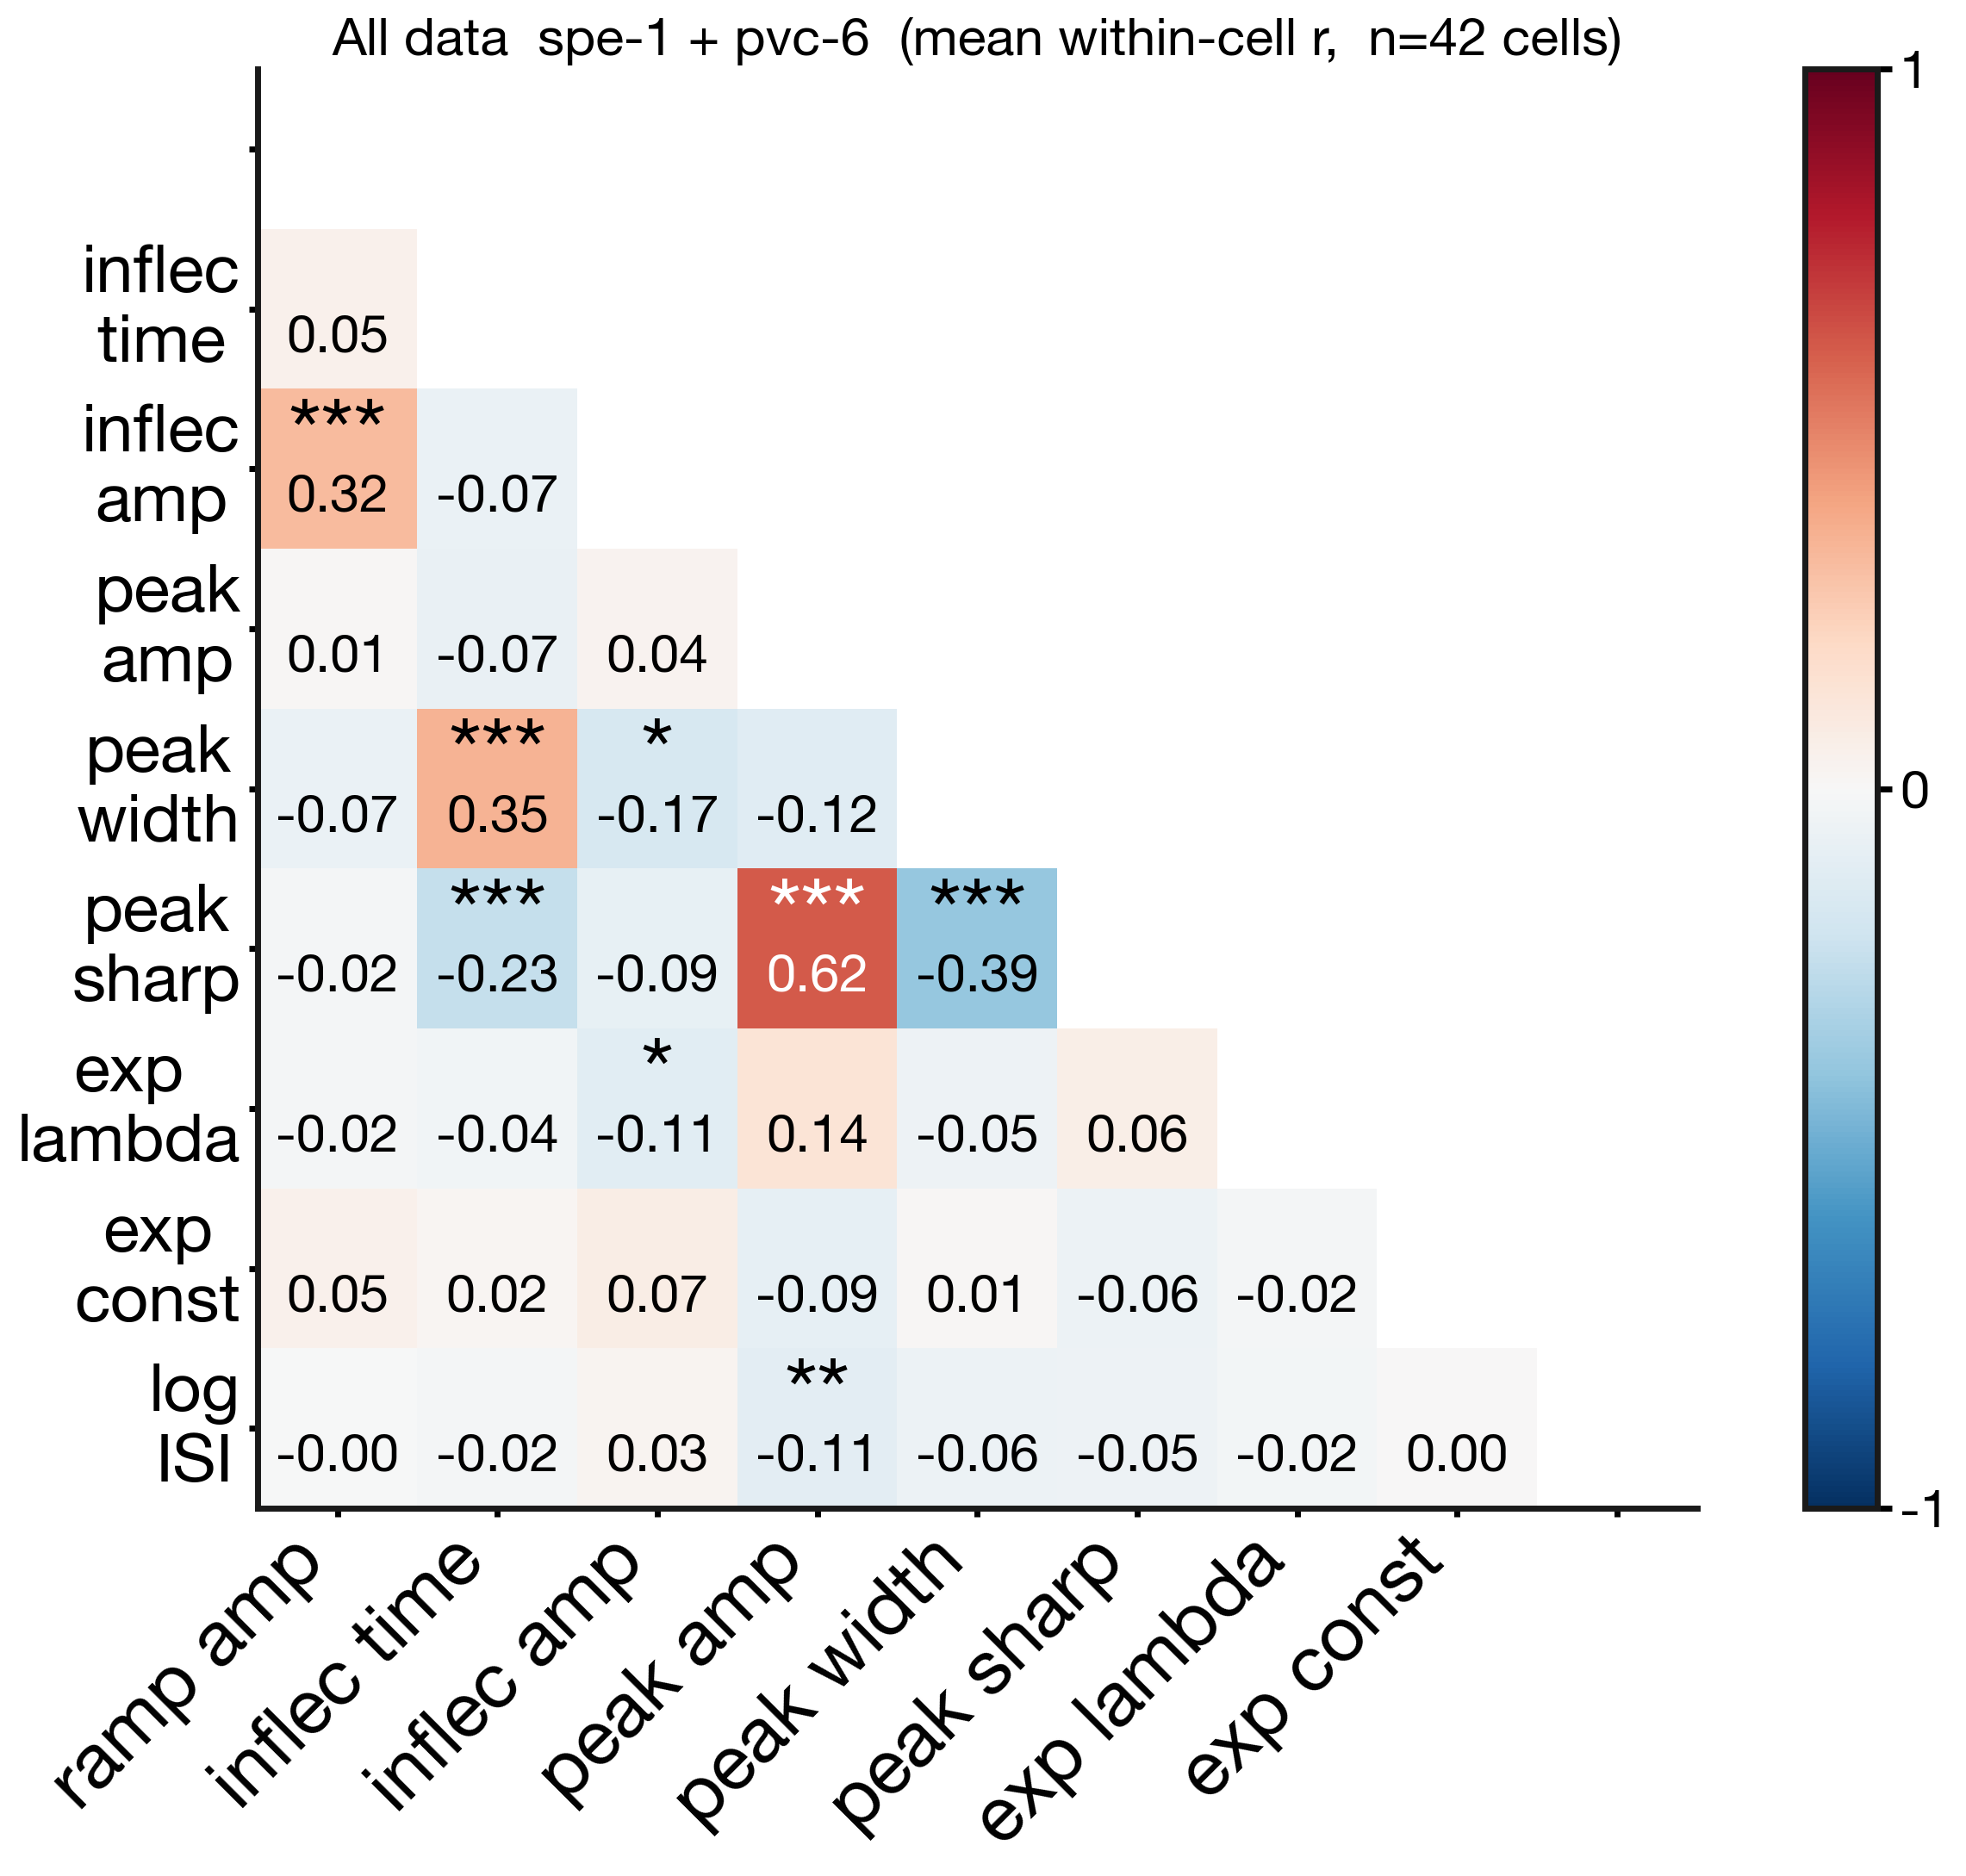

In [9]:
dfs_all_datasets = dfs_all + [df_pvc6_c1, df_pvc6_c2]
mean_r_all, pval_all, n_all = compute_within_cell_avg_corr(dfs_all_datasets, SPK_FEATS)
print(f'total cells used: {n_all}')
plot_avg_corr_heatmap(
    mean_r_all, pval_all, SPK_FEATS,
    title=f'All data  spe-1 + pvc-6  (mean within-cell r,  n={n_all} cells)'
)

## 6. Representative spe-1 cells — IN and PC with most spikes

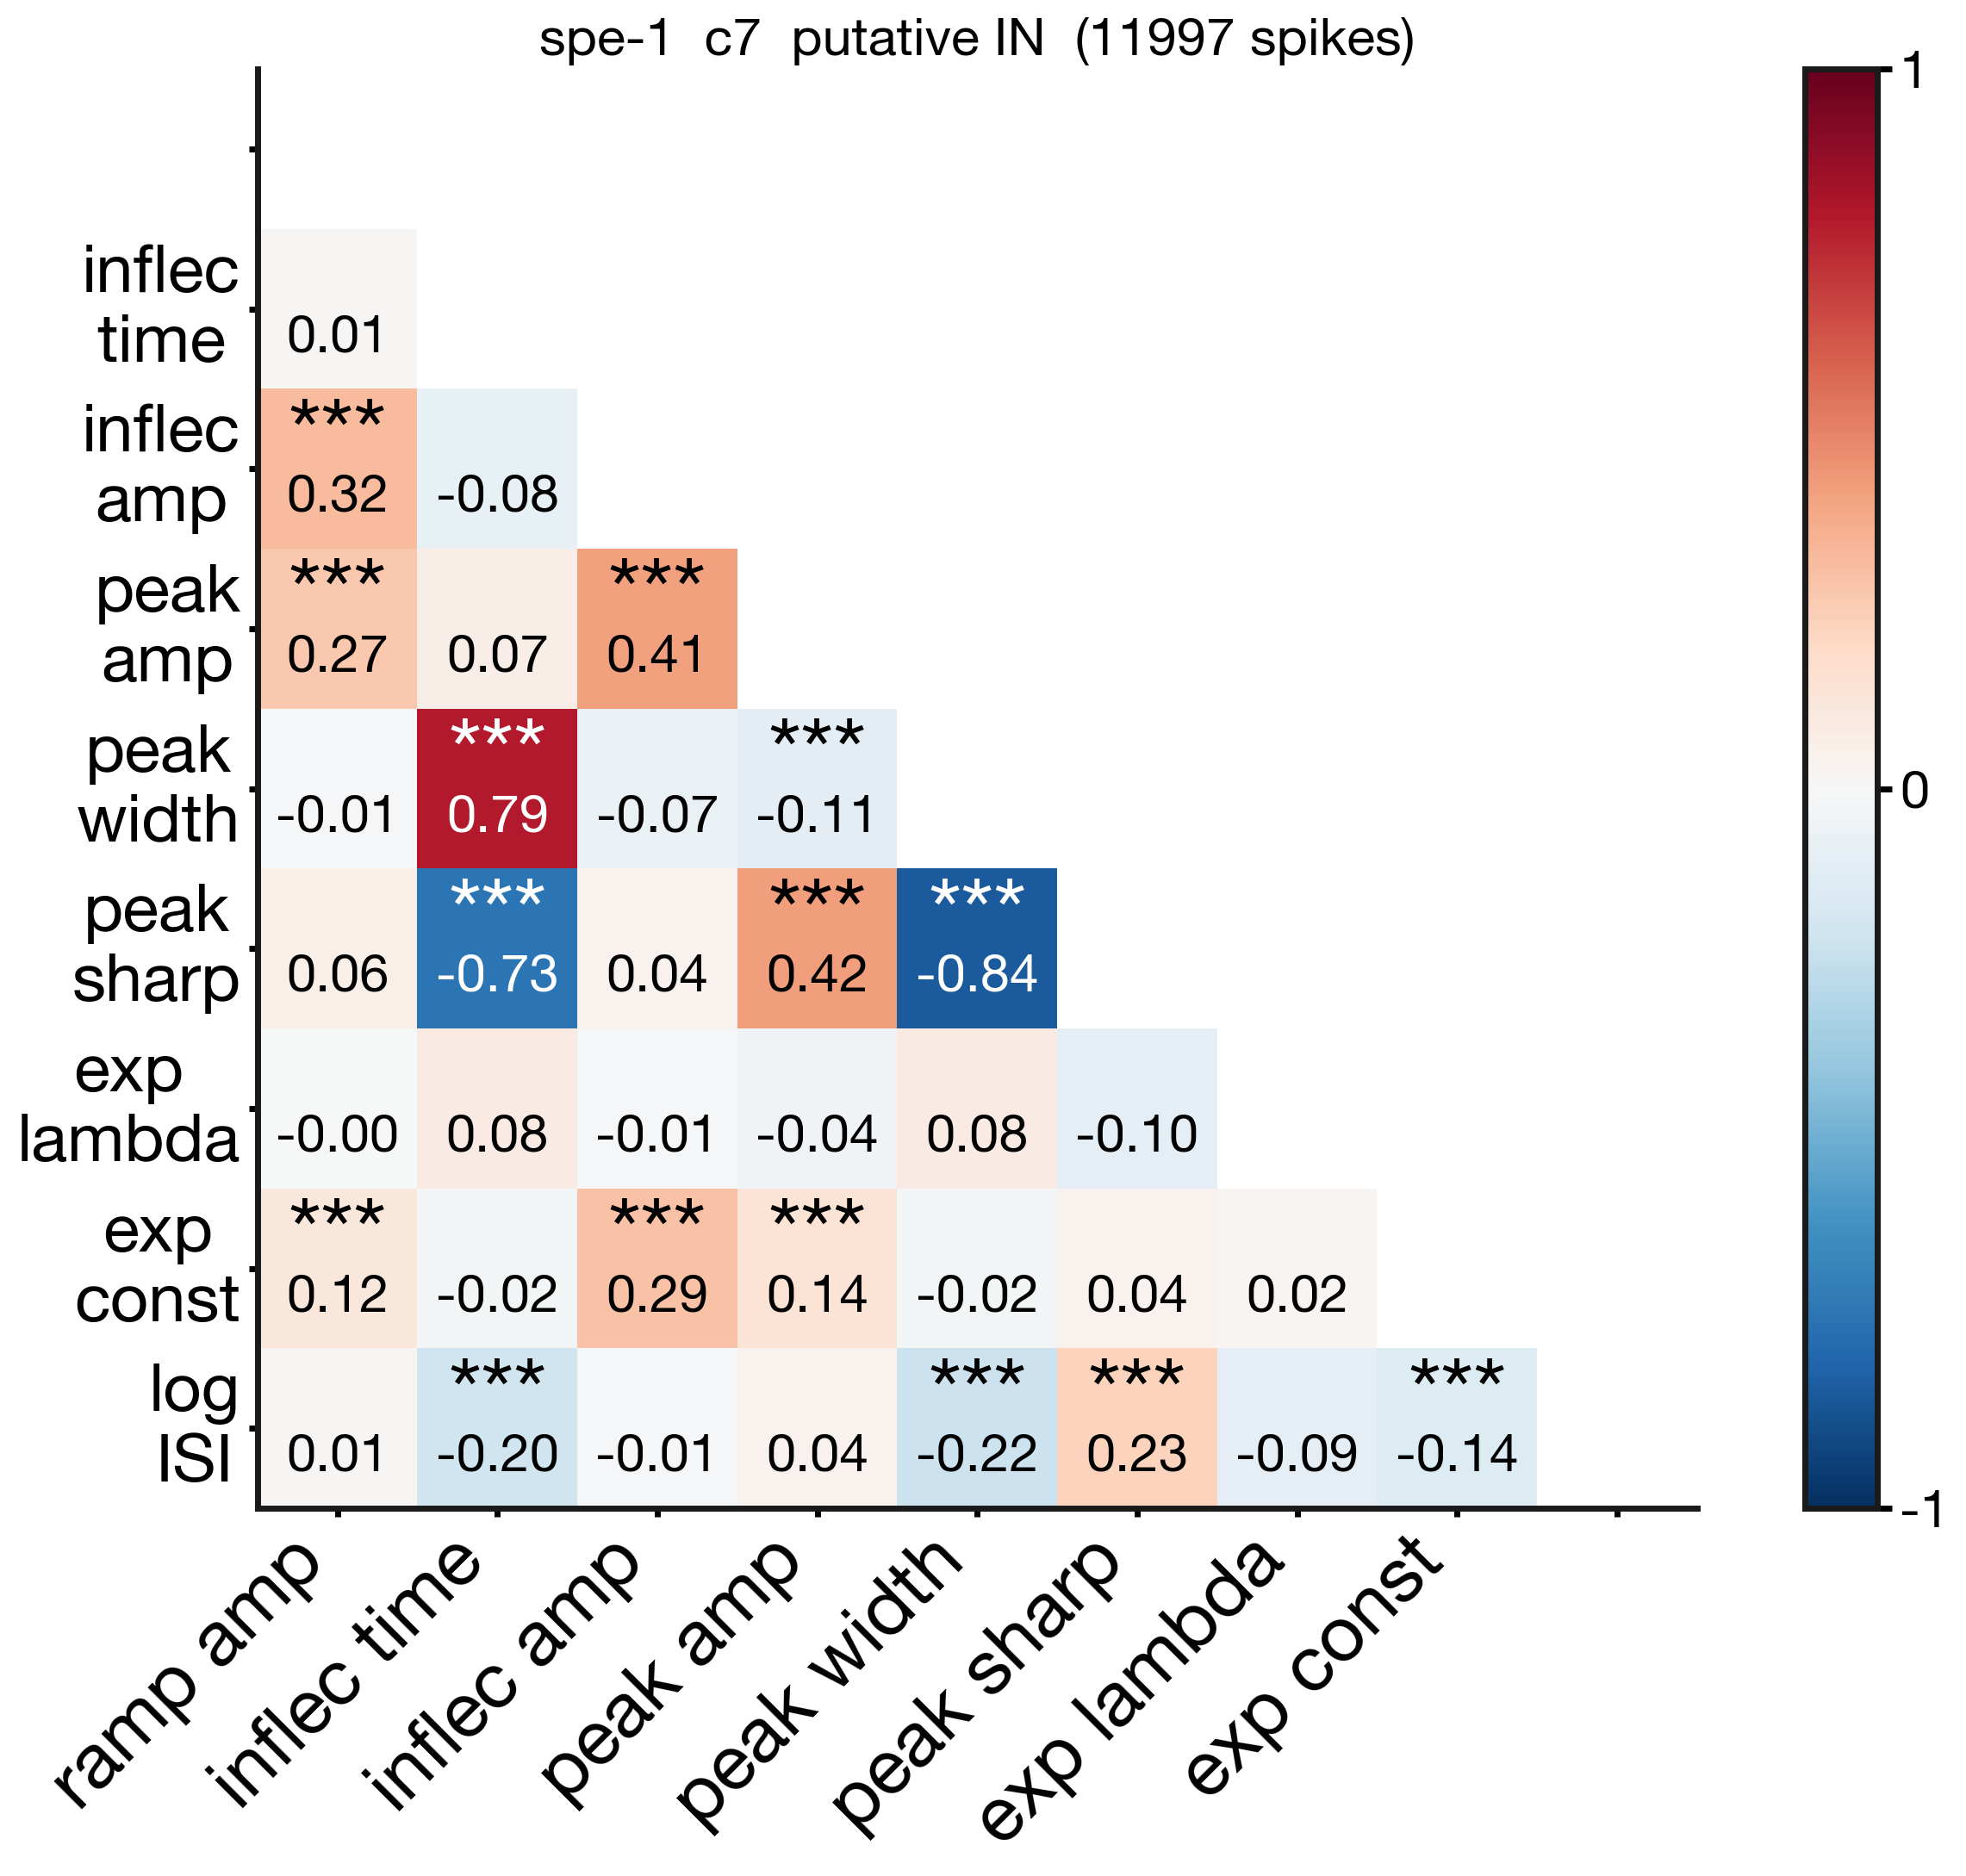

In [10]:
plot_corr_heatmap_only_spk(
    best_in_df,
    SPK_FEATS,
    title=f'spe-1  {best_in_cid}  putative IN  ({len(best_in_df)} spikes)'
)

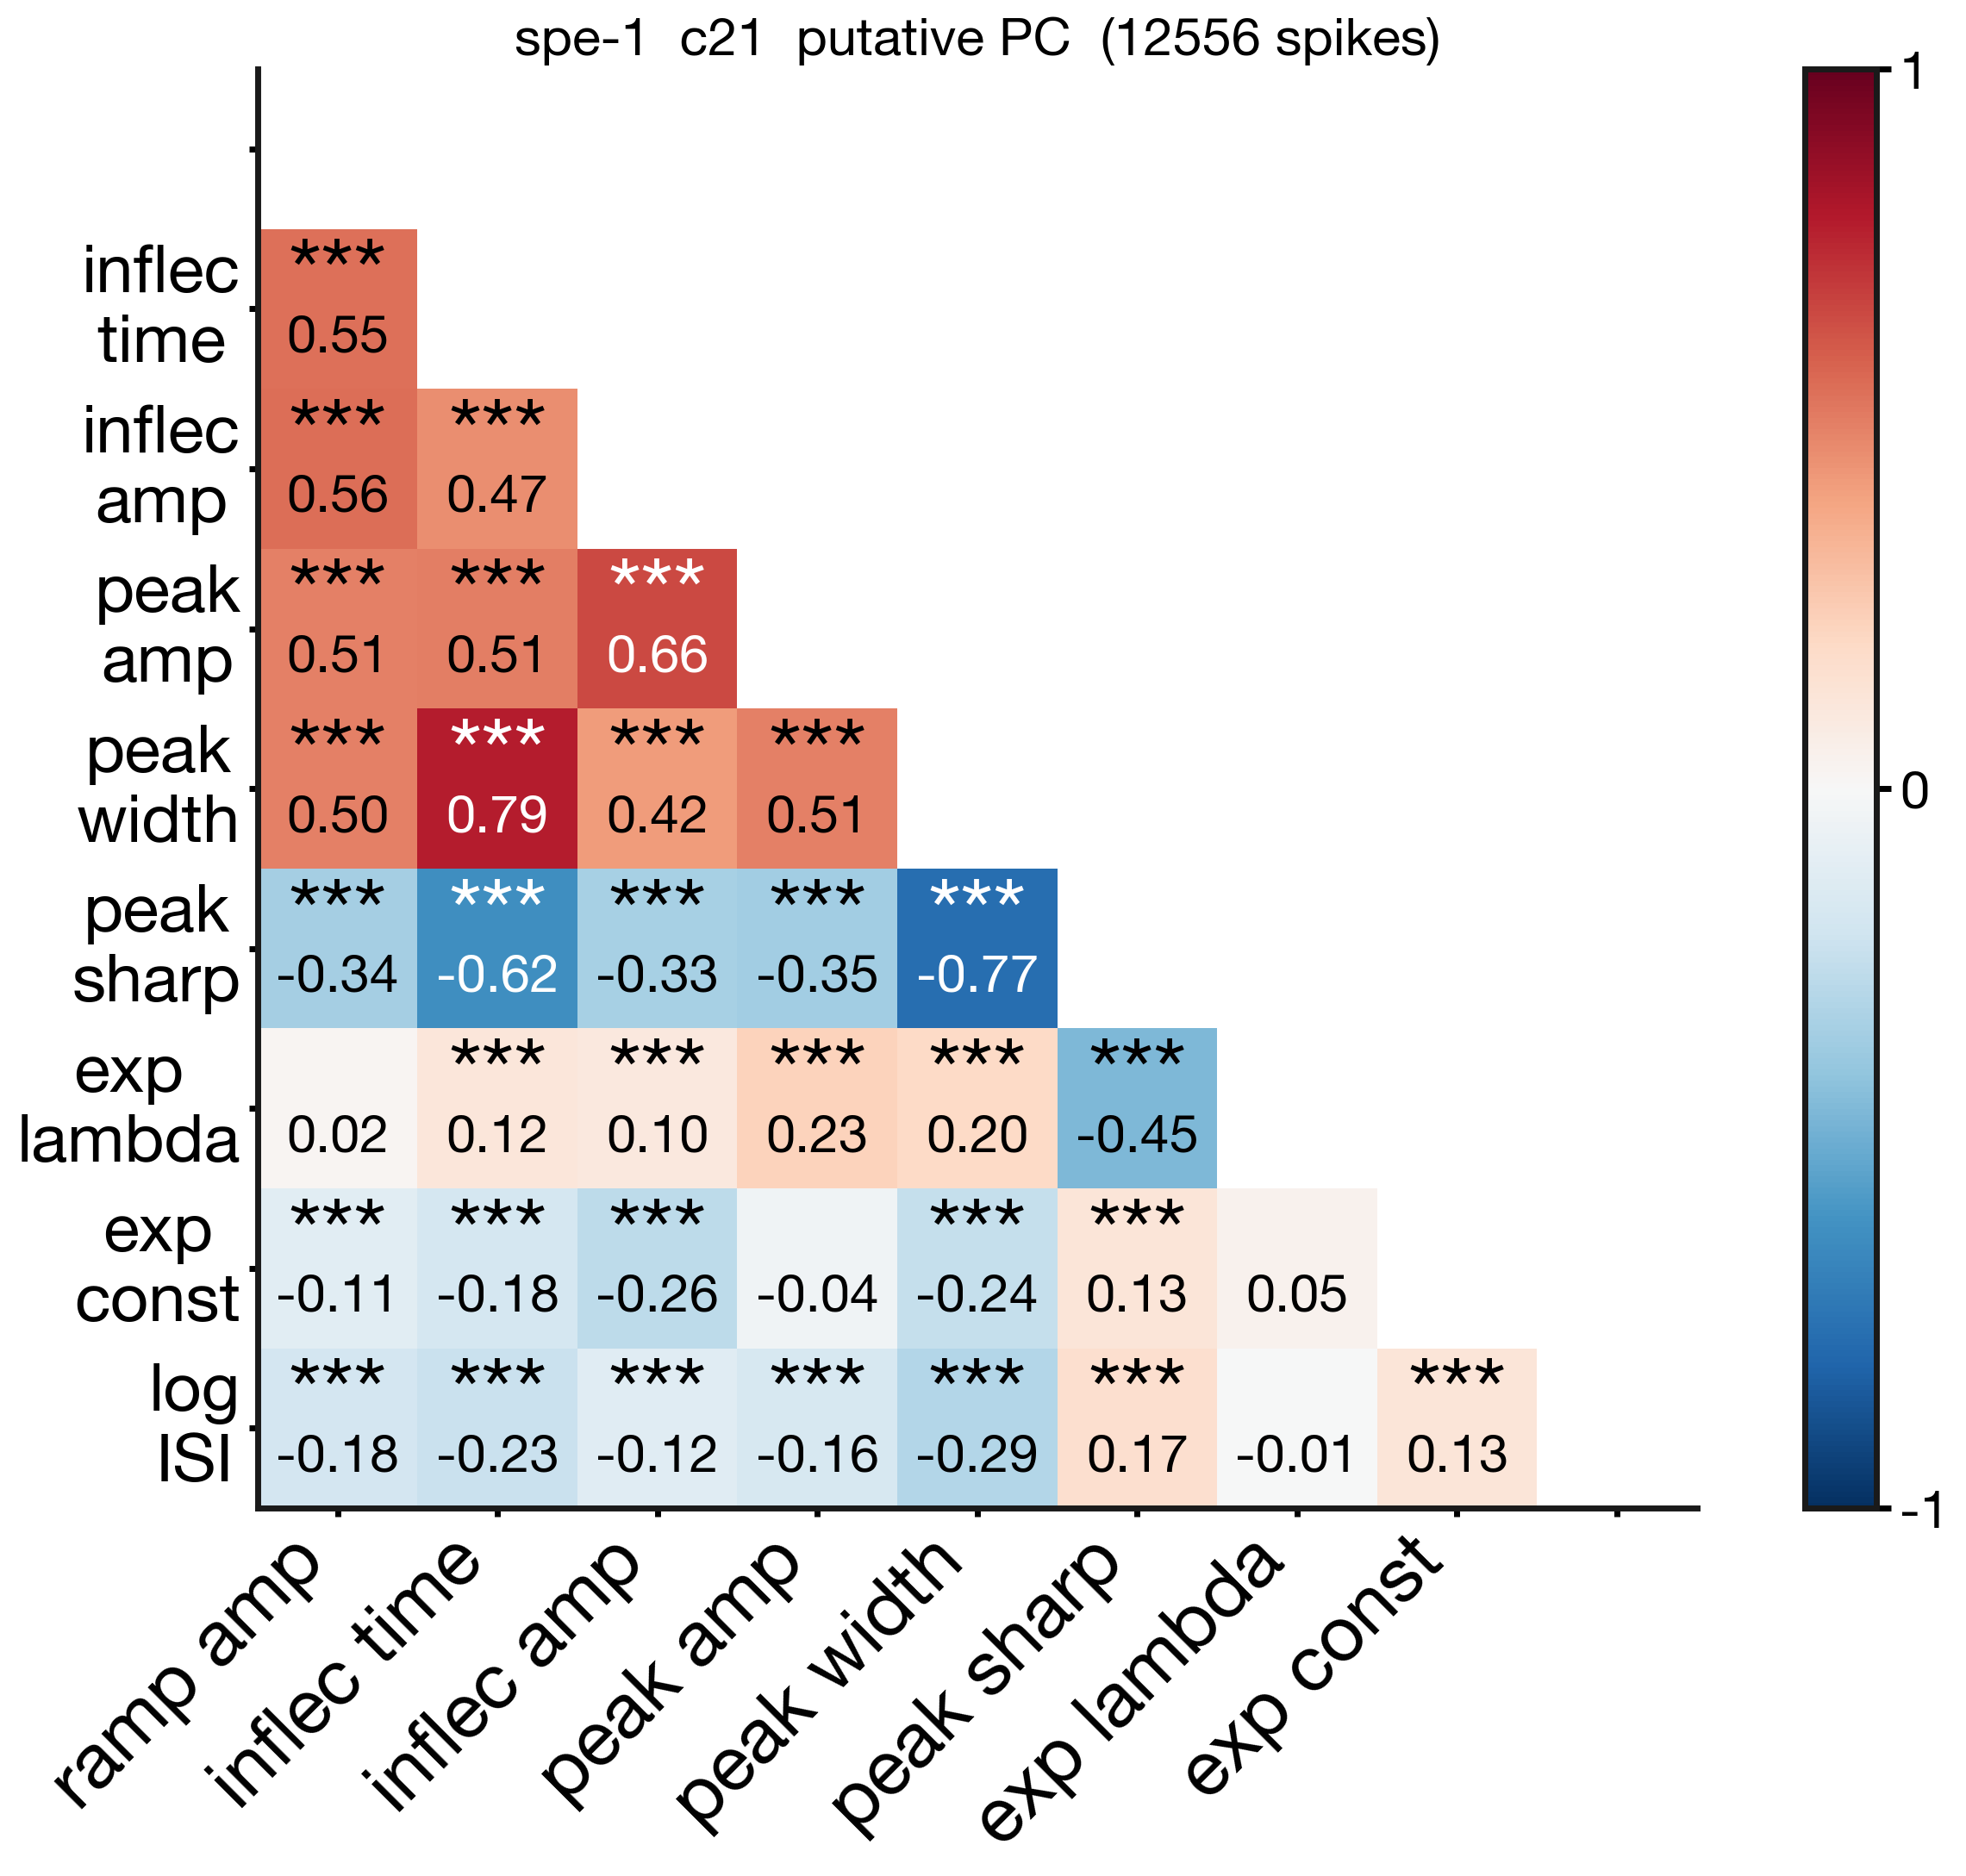

In [11]:
plot_corr_heatmap_only_spk(
    best_pc_df,
    SPK_FEATS,
    title=f'spe-1  {best_pc_cid}  putative PC  ({len(best_pc_df)} spikes)'
)